# 本小节核心是介绍AI模型是如何处理字符数据的

## AI项目开发流程
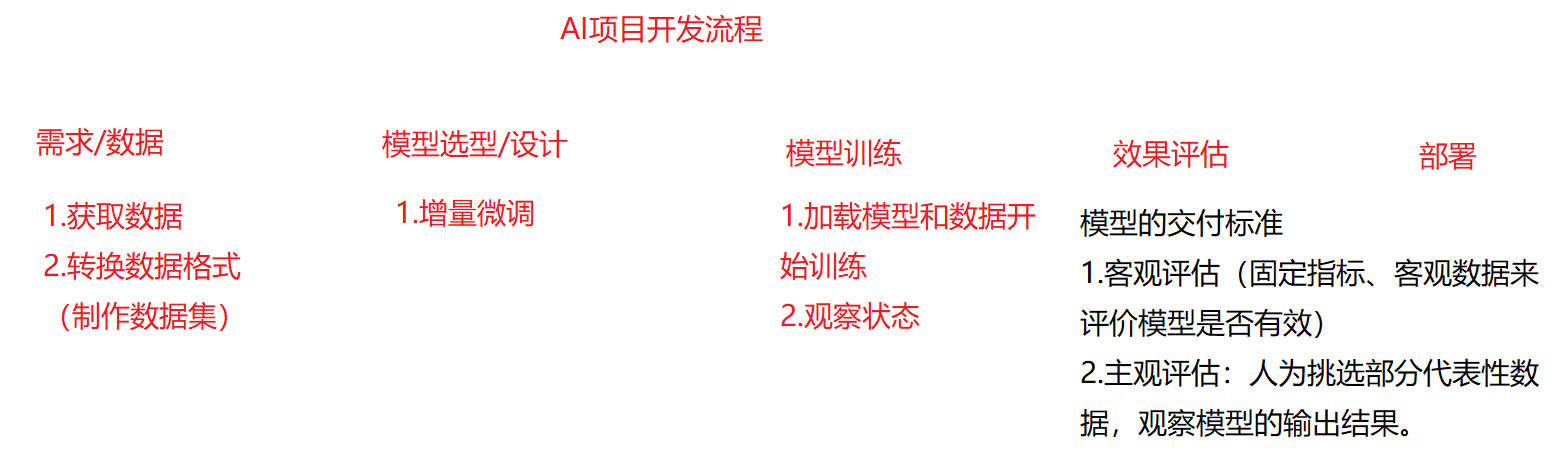

## 字符编码和解码

In [1]:
#加载字典和分词器
from transformers import BertTokenizer
token=BertTokenizer.from_pretrained(r"D:\AI\model\bert-base-chinese\models--bert-base-chinese\snapshots\c30a6ed22ab4564dc1e3b2ecbf6e766b0611a33f")
#print(token)

#准备要编码的文本数据
sents = ["白日依山尽，",
         "价格在这个地段属于适中, 附近有早餐店,小饭店, 比较方便,无早也无所"]
#批量编码句子
out=token.batch_encode_plus(
    batch_text_or_text_pairs=[sents[0],sents[1]],#传入句子
    add_special_tokens=True,#是否添加特殊字符
    truncation=True,#是否截断，当句子长度大于max_length是就截断
    max_length=8,#max_length的上限是512，
    padding="max_length",#如果没达到则一律补0到max_length
    return_tensors=None,#编码后返回数值的类型，可取值为tf,pt,np,给None默认为list
    return_attention_mask=True,
    return_token_type_ids=True,
    return_speaker_ids=True,
    return_length=True#返回序列长度
)

for k,v in out.items():
    print(k,":",v)

#解码文本数据
print(token.decode(out["input_ids"][0]),token.decode(out["input_ids"][1]))


Keyword arguments {'return_speaker_ids': True} not recognized.
Keyword arguments {'return_speaker_ids': True} not recognized.


input_ids : [[101, 4635, 3189, 898, 2255, 2226, 8024, 102], [101, 817, 3419, 1762, 6821, 702, 1765, 102]]
token_type_ids : [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]]
length : [8, 8]
attention_mask : [[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1]]
[CLS] 白 日 依 山 尽 ， [SEP] [CLS] 价 格 在 这 个 地 [SEP]


## 数据获取

### 访问Hugging Face

开启科学上网，访问Hugging Face
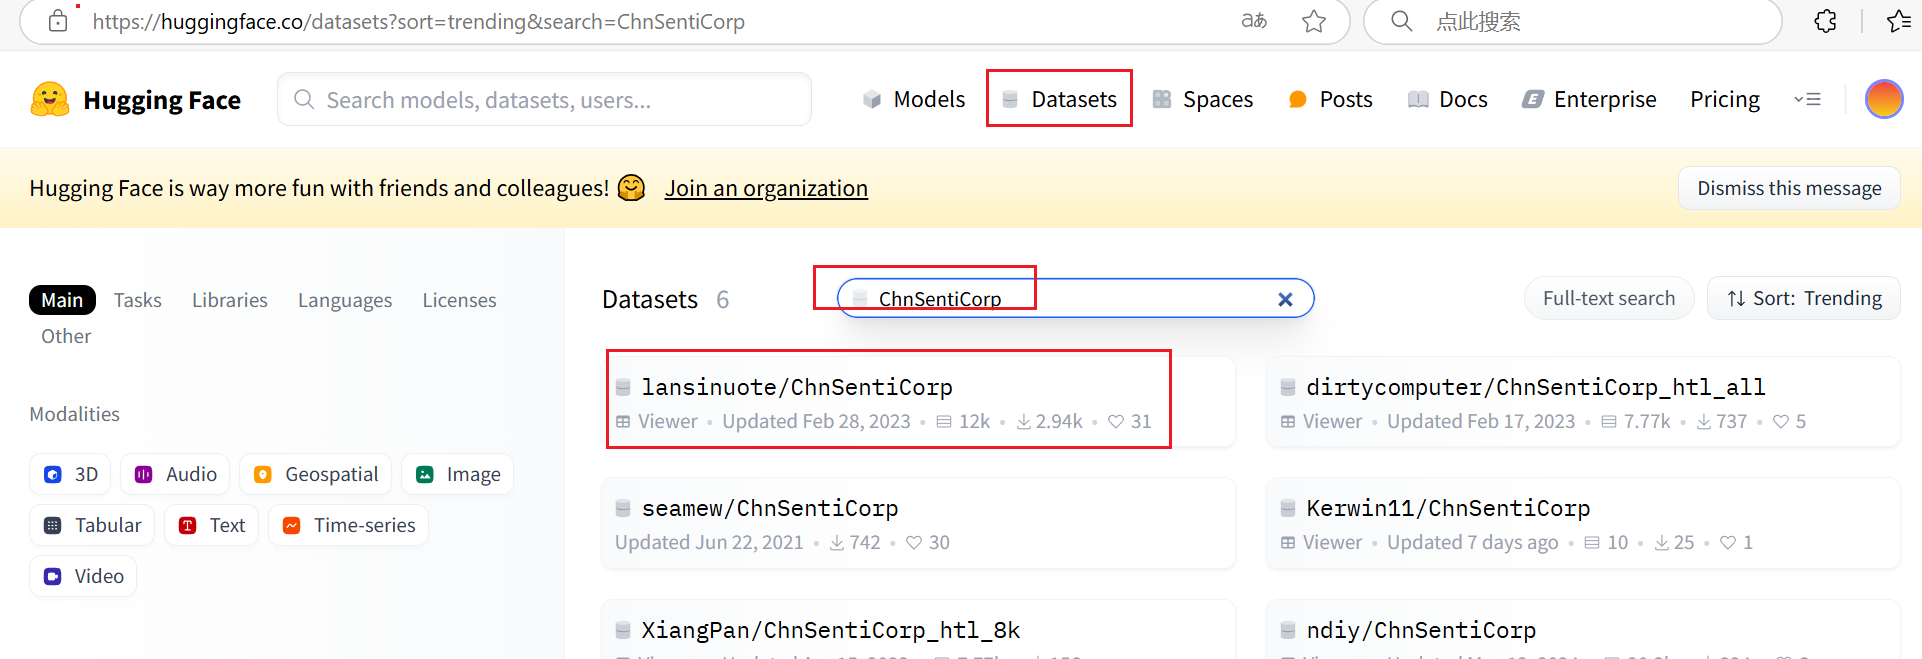

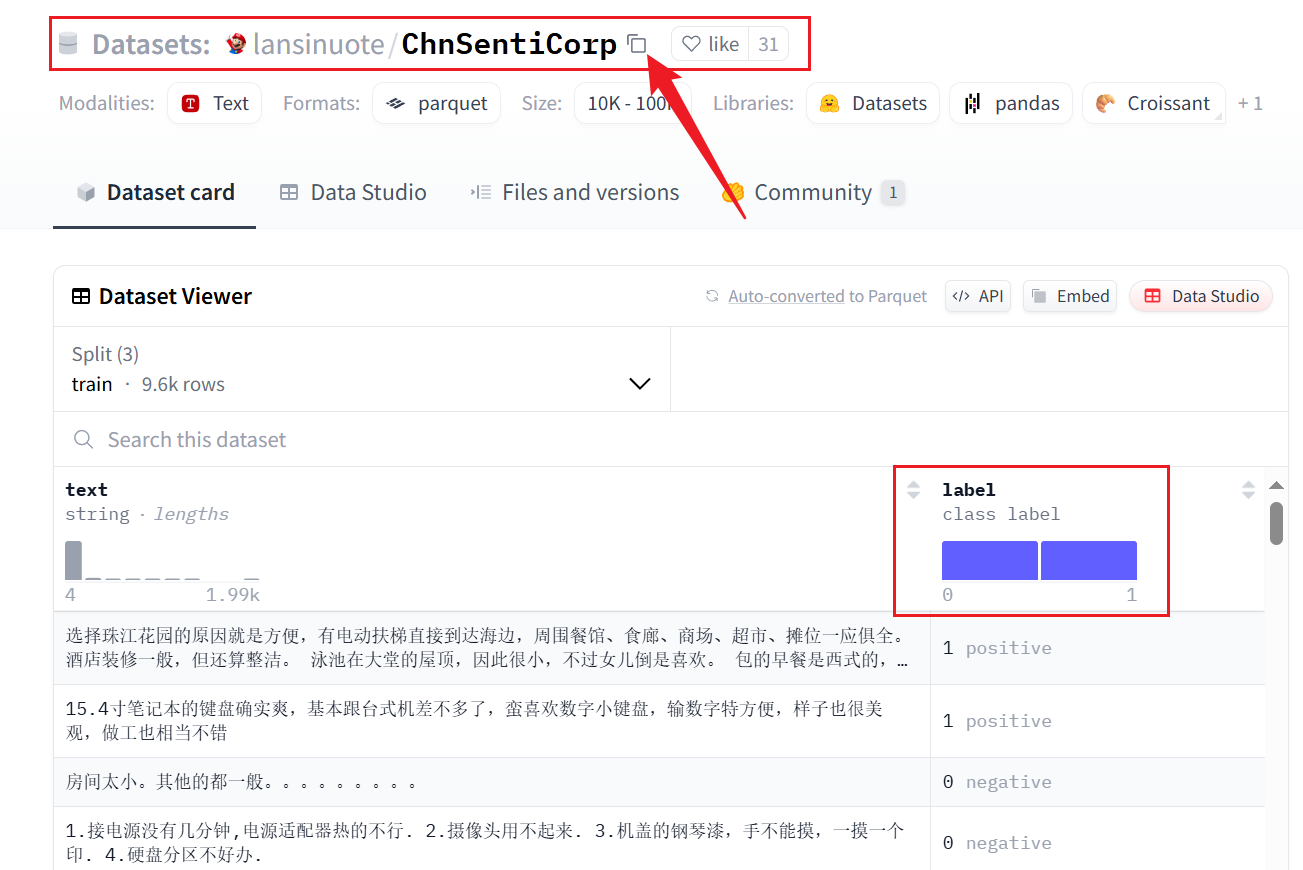

### 从huggingface下载

In [ ]:

from datasets import load_dataset,load_from_disk

#在线加载数据集,加载的是中文情感分析数据集,包含两个类别，正面和负面,注意开启科学上网
#如果不设置目录则默认保存在本地的C:\Users\admin\.cache\huggingface\datasets
#dataset = load_dataset(path="lansinuote/ChnSentiCorp")
dataset = load_dataset(path="lansinuote/ChnSentiCorp",cache_dir="data/")
print(dataset)


### 加载下载好的数据

In [2]:
from datasets import load_dataset,load_from_disk
#加载缓存数据集，用到load_from_disk这个包,要给绝对路径，路径给到dataset_info.json文件的所在目录
#如果加载错误，可能是路径不对，或者路径下没有dataset_info.json文件，或者换一个数据集试试
dataset = load_from_disk(r"D:\AI\data\ChnSentiCorp")
print(dataset)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9600
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1200
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1200
    })
})


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9600
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1200
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1200
    })
})
在输出中，分为训练、验证、和测试三个部分

### 查看数据集

In [3]:
train_dataset = dataset["train"]
for data in train_dataset:
    print(data)

{'text': '选择珠江花园的原因就是方便，有电动扶梯直接到达海边，周围餐馆、食廊、商场、超市、摊位一应俱全。酒店装修一般，但还算整洁。 泳池在大堂的屋顶，因此很小，不过女儿倒是喜欢。 包的早餐是西式的，还算丰富。 服务吗，一般', 'label': 1}
{'text': '15.4寸笔记本的键盘确实爽，基本跟台式机差不多了，蛮喜欢数字小键盘，输数字特方便，样子也很美观，做工也相当不错', 'label': 1}
{'text': '房间太小。其他的都一般。。。。。。。。。', 'label': 0}
{'text': '1.接电源没有几分钟,电源适配器热的不行. 2.摄像头用不起来. 3.机盖的钢琴漆，手不能摸，一摸一个印. 4.硬盘分区不好办.', 'label': 0}
{'text': '今天才知道这书还有第6卷,真有点郁闷:为什么同一套书有两种版本呢?当当网是不是该跟出版社商量商量,单独出个第6卷,让我们的孩子不会有所遗憾。', 'label': 1}
{'text': '机器背面似乎被撕了张什么标签，残胶还在。但是又看不出是什么标签不见了，该有的都在，怪', 'label': 0}
{'text': '呵呵，虽然表皮看上去不错很精致，但是我还是能看得出来是盗的。但是里面的内容真的不错，我妈爱看，我自己也学着找一些穴位。', 'label': 0}
{'text': '这本书实在是太烂了,以前听浙大的老师说这本书怎么怎么不对,哪些地方都是误导的还不相信,终于买了一本看一下,发现真是~~~无语,这种书都写得出来', 'label': 0}
{'text': '地理位置佳，在市中心。酒店服务好、早餐品种丰富。我住的商务数码房电脑宽带速度满意,房间还算干净，离湖南路小吃街近。', 'label': 1}
{'text': '5.1期间在这住的，位置还可以，在市委市政府附近，要去商业区和步行街得打车，屋里有蚊子，虽然空间挺大，晚上熄灯后把窗帘拉上简直是伸手不见五指，很适合睡觉，但是会被该死的蚊子吵醒！打死了两只，第二天早上还是发现又没打死的，卫生间挺大，但是设备很老旧。', 'label': 1}
{'text': '我看过朋友的还可以，但是我订的书迟迟未到已有半个月，都没有收到打电话也没有用，以后你们订书一定要考虑好！当当实在是太慢了', 'label':

### 拓展：加载csv数据

In [4]:
dataset=load_dataset(path="csv",data_files=r"D:\AI\data\hermes-function-calling-v1.csv")
print(dataset)

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'conversations', 'category', 'subcategory', 'task'],
        num_rows: 1893
    })
})


## 制作数据集（转换数据格式）

In [6]:
from torch.utils.data import Dataset
from datasets import load_from_disk
#新建一个类，继承pytorch的Dataset类,重写__init__,__len__,__getitem__方法
class MyDataset(Dataset):
    def __init__(self,split):#初始化数据集
        #从磁盘加载数据集
        self.dataset=load_from_disk(r"D:\AI\data\ChnSentiCorp")
        if "train"==split:
            self.dataset=self.dataset["train"]
        elif "test"==split:
            self.dataset=self.dataset["test"]
        elif "validation"==split:
            self.dataset=self.dataset["validation"]
        else:
            print("split参数错误")

    def __len__(self):#返回数据集的长度
        return len(self.dataset)
    
    def __getitem__(self, idx):#返回数据集的第idx个数据，对每条数据进行单独处理
        text=self.dataset[idx]["text"]
        label=self.dataset[idx]["label"]
        return text,label

#测试
if __name__=="__main__":
    dataset=MyDataset("test")
    for data in dataset:
        print(data)

    item= dataset.__getitem__(1)
    print(item)


('这个宾馆比较陈旧了，特价的房间也很一般。总体来说一般', 1)
('怀着十分激动的心情放映，可是看着看着发现，在放映完毕后，出现一集米老鼠的动画片！开始还怀疑是不是赠送的个别现象，可是后来发现每张DVD后面都有！真不知道生产商怎么想的，我想看的是猫和老鼠，不是米老鼠！如果厂家是想赠送的话，那就全套米老鼠和唐老鸭都赠送，只在每张DVD后面添加一集算什么？？简直是画蛇添足！！', 0)
('还稍微重了点，可能是硬盘大的原故，还要再轻半斤就好了。其他要进一步验证。贴的几种膜气泡较多，用不了多久就要更换了，屏幕膜稍好点，但比没有要强多了。建议配赠几张膜让用用户自己贴。', 0)
('交通方便；环境很好；服务态度很好 房间较小', 1)
('不错，作者的观点很颠覆目前中国父母的教育方式，其实古人们对于教育已经有了很系统的体系了，可是现在的父母以及祖父母们更多的娇惯纵容孩子，放眼看去自私的孩子是大多数，父母觉得自己的孩子在外面只要不吃亏就是好事，完全把古人几千年总结的教育古训抛在的九霄云外。所以推荐准妈妈们可以在等待宝宝降临的时候，好好学习一下，怎么把孩子教育成一个有爱心、有责任心、宽容、大度的人。', 1)
('有了第一本书的铺垫，读第二本的时候开始进入状态。基本上第二本就围绕主角们的能力训练展开，故事的主要发生场地设置在美洲的亚马逊丛林。心里一直疑惑这和西藏有什么关系，不过大概看完全书才能知道内里的线索。其中描述了很多热带雨林中特有的神秘动植物以及一些生存技巧和常识，受益匪浅。能够想像出要写这样一部书，融合这样许多的知识，作者需要花费多少心血来搜集和整理并成文。', 1)
('前台接待太差，酒店有A B楼之分，本人check－in后，前台未告诉B楼在何处，并且B楼无明显指示；房间太小，根本不像4星级设施，下次不会再选择入住此店啦。', 0)
('1. 白色的，很漂亮，做工还可以； 2. 网上的软件资源非常丰富，这是我买它的最主要原因； 3. 电池不错，昨天从下午两点到晚上十点还有25分钟的剩余时间（关闭摄像头，无线和蓝牙）主要拷贝东西，看起来正常使用八小时左右没问题； 4. 散热不错，CPU核心不过40~55度，很多小本要上到80度了； 5. 变压器很小巧，很多小本的电源都用的是大本的电源，本倒是很轻，可旅行重量还是比较重。', 1)
('在当当上买了很多书，都懒于评论

## 模型设计

In [9]:
import torch
from transformers import BertModel

#定义设备信息
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

#加载预训练模型,注意结尾的to(DEVICE)是将模型加载到设备上，是cpu还是gpu取决于DEVICE
pretrained=BertModel.from_pretrained(r"D:\AI\model\bert-base-chinese\models--bert-base-chinese\snapshots\c30a6ed22ab4564dc1e3b2ecbf6e766b0611a33f").to(DEVICE)
print(pretrained)

#定义下游任务模型（增量模型）
class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        #设计全连接网络，实现二分类任务
        self.fc=torch.nn.Linear(in_features=768,out_features=2)
 
#使用模型处理数据（执行前向计算）
def forward(self,input_ids,attention_mask,token_type_ids):
    #冻结Bert模型的参数,让其不参与训练
    with torch.no_grad():
        #获取Bert模型的输出
        output=pretrained(input_ids=input_ids,attention_mask=attention_mask,token_type_ids=token_type_ids)

    #增量模型参与训练
    output=self.fc(output.last_hidden_state[:,0])#取出最后的序列特征，最后一段序列特征包含完整的句子信息
    return output



cuda
BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(21128, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=

## 模型训练

In [1]:
#导入模型用
import torch

from MyData import MyDataset
#用于加载数据集
from torch.utils.data import DataLoader
#用于加载刚刚设计的模型
from net import Model
#用于加载预训练模型,BertTokenizer是用于加载字典和分词器，AdamW是用于加载优化器
from transformers import BertTokenizer
from torch.optim import AdamW #AdamW是用于加载优化器
#定义设备信息
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")

#定义训练的轮次（将整个数据集训练完一次为一个轮次）
EPOCH=30000
#加载字典和分词器
token=BertTokenizer.from_pretrained(r"D:\AI\model\bert-base-chinese\models--bert-base-chinese\snapshots\c30a6ed22ab4564dc1e3b2ecbf6e766b0611a33f")

#将传进来的字符串数据进行编码
def collate_fn(data):
    sents=[i[0] for i in data]
    labels=[i[1] for i in data]
    #批量编码句子
    data=token.batch_encode_plus(
        batch_text_or_text_pairs=sents,#传入句子
        truncation=True,#是否截断，当句子长度大于max_length是就截断
        max_length=512,#max_length的上限是512，
        padding="max_length",#如果没达到则一律补0到max_length
        return_tensors="pt",#编码后返回数值的类型，可取值为tf,pt,np,给None默认为list
        return_length=True#返回序列长度
    )

    input_ids=data["input_ids"]
    attention_mask=data["attention_mask"]
    token_type_ids=data["token_type_ids"]
    labels=torch.LongTensor(labels)
    return input_ids,attention_mask,token_type_ids,labels

#创建数据集
train_dataset=MyDataset("train")
#取数据
train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=450,#每次取几条数据，超参数，让GPU能显存占用90%左右，如果cpu怎内存占用90%左右
    shuffle=True,#是否打乱数据
    drop_last=True,#是否丢弃最后一个不足batch_size的batch
    collate_fn=collate_fn#是否自定义数据集的处理方式
    )



cuda
BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(21128, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=

In [ ]:


if __name__=="__main__":
    #开始训练
    print(DEVICE)
    model=Model().to(DEVICE)
    #定义优化器
    optimizer=AdamW(model.parameters())
    #定义损失函数
    loss_func=torch.nn.CrossEntropyLoss()

    #创建一个文件夹params，用于保存模型参数
    import os
    if not os.path.exists("params"):
        os.mkdir("params")
        
    for epoch in range(EPOCH):
        for i,(input_ids,attention_mask,token_type_ids,labels) in enumerate(train_loader):
            #将数据加载到设备上
            input_ids, attention_mask, token_type_ids
            input_ids=input_ids.to(DEVICE)
            attention_mask=attention_mask.to(DEVICE)
            token_type_ids=token_type_ids.to(DEVICE)
            labels=labels.to(DEVICE)

            #前向计算(将数据输入模型，得到输出)
            output=model(input_ids,attention_mask,token_type_ids)
            #根据输出和标签计算损失
            loss=loss_func(output,labels)
            #梯度清零
            optimizer.zero_grad()
            #反向传播
            loss.backward()
            #更新参数
            optimizer.step()
            print(f"loss:{loss.item()}")

            #每隔5个批次输出训练信息
            if 0==i%5:
                output=output.argmax(dim=1)
                #计算训练精度
                acc=(output==labels).sum().item()/len(labels)
                print(f"epoch:{epoch},i:{i},loss:{loss.item()},acc:{acc}")

            
        #保存模型
        torch.save(model.state_dict(),f"params/{epoch}_bert.pth")
        print(epoch,"参数保存成功！")




## 模型测试
### 训练模时候需要观察的指标
#### 1、训练损失-train_loss
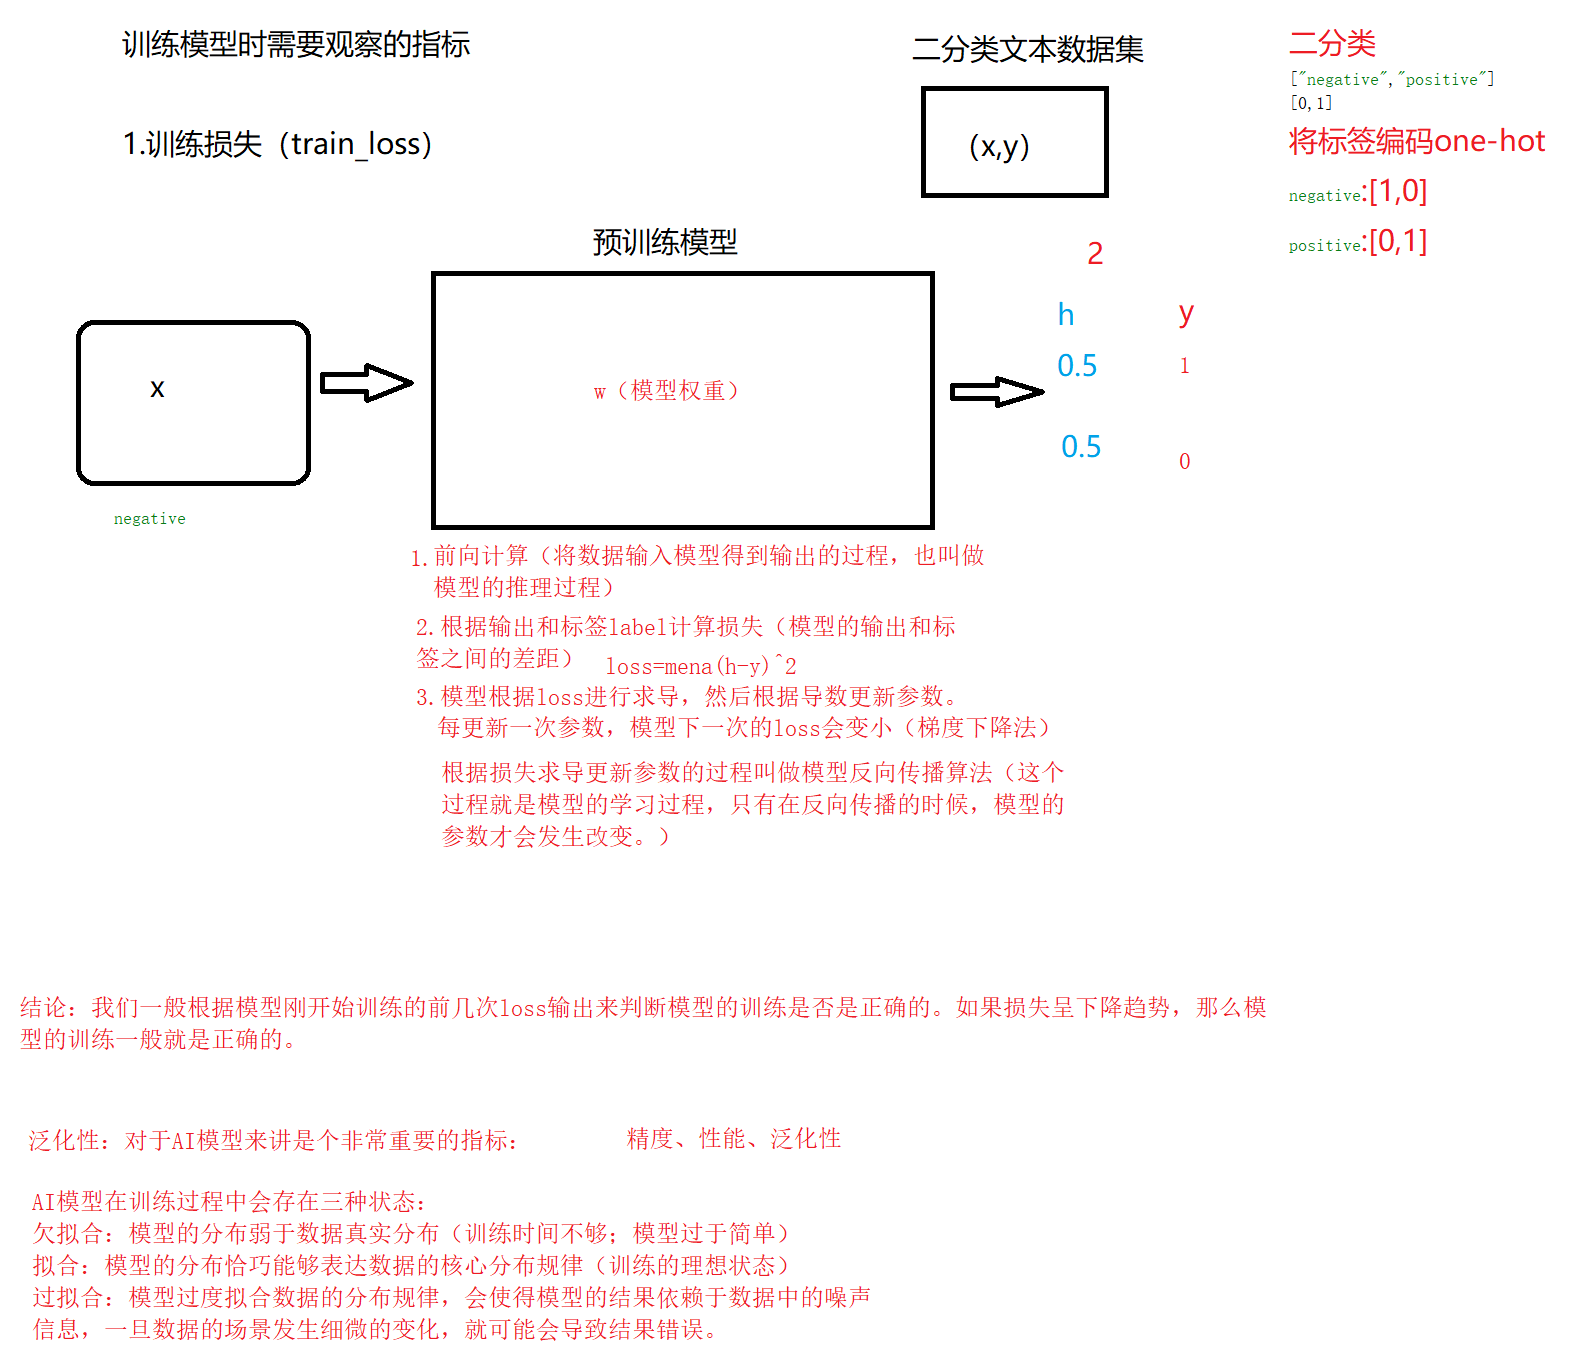








### 模型测试（客观评估）-test.py

In [10]:
#导入模型用
import torch

from MyData import MyDataset
#用于加载数据集
from torch.utils.data import DataLoader
#用于加载刚刚设计的模型
from net import Model
#用于加载预训练模型,BertTokenizer是用于加载字典和分词器，AdamW是用于加载优化器
from transformers import BertTokenizer
from torch.optim import AdamW #AdamW是用于加载优化器

#定义设备信息
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#加载字典和分词器
token=BertTokenizer.from_pretrained(r"D:\AI\model\bert-base-chinese\models--bert-base-chinese\snapshots\c30a6ed22ab4564dc1e3b2ecbf6e766b0611a33f")

#将传进来的字符串数据进行编码
def collate_fn(data):
    sents=[i[0] for i in data]
    labels=[i[1] for i in data]
    #批量编码句子
    data=token.batch_encode_plus(
        batch_text_or_text_pairs=sents,#传入句子
        truncation=True,#是否截断，当句子长度大于max_length是就截断
        max_length=512,#max_length的上限是512，!!!!注意，测试时候的这长度一定要和训练时候保持一直
        padding="max_length",#如果没达到则一律补0到max_length
        return_tensors="pt",#编码后返回数值的类型，可取值为tf,pt,np,给None默认为list
        return_length=True#返回序列长度
    )

    input_ids=data["input_ids"]
    attention_mask=data["attention_mask"]
    token_type_ids=data["token_type_ids"]
    labels=torch.LongTensor(labels)
    return input_ids,attention_mask,token_type_ids,labels


#创建数据集
test_dataset=MyDataset("test")
#取数据
test_loader=DataLoader(
    dataset=test_dataset,
    batch_size=100,#批次要和训练时候保持一致，甚至要尽量保持训练的设备和测试的设备是同一个
    shuffle=True,#是否打乱数据
    drop_last=True,#是否丢弃最后一个不足batch_size的batch
    collate_fn=collate_fn#是否自定义数据集的处理方式
    )


if __name__=="__main__":

    acc=0.0#精度
    total=0#数据总的数量

    #开始训练
    print(DEVICE)
    model=Model().to(DEVICE)
    #加载模型训练参数
    model.load_state_dict(torch.load("params/148_bert.pth"))
    #开启测试模式
    model.eval()

    for i,(input_ids,attention_mask,token_type_ids,labels) in enumerate(test_loader):
        #将数据加载到设备上
        input_ids=input_ids.to(DEVICE)
        attention_mask=attention_mask.to(DEVICE)
        token_type_ids=token_type_ids.to(DEVICE)
        labels=labels.to(DEVICE)

        #前向计算(将数据输入模型，得到输出)
        out=model(input_ids,attention_mask,token_type_ids)

        out = out.argmax(dim=1)#将结果中的两个小数取概率较大的index，目的是转换成和label一样的形式

        acc+=(out==labels).sum().item()#判断输出和测的标签是否相同，相同则进行累加
        print(i,(out==labels).sum().item())
        total+=len(labels)
    print(f"test acc:{acc/total:.4f}")







cuda


C:\Users\admin\AppData\Local\Temp\ipykernel_13192\2412880883.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("params/148_bert.pth"))


0 93
1 93
2 87
3 91
4 90
5 95
6 92
7 87
8 90
9 93
10 89
11 96
test acc:0.9133


### 模型测试（主观评估/模型使用接口）-run.py

In [ ]:
#模型使用接口
#导入模型用
import torch
#用于加载刚刚设计的模型
from net import Model
#用于加载预训练模型,BertTokenizer是用于加载字典和分词器，AdamW是用于加载优化器
from transformers import BertTokenizer

#定义设备信息
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#加载字典和分词器
token=BertTokenizer.from_pretrained(r"D:\AI\model\bert-base-chinese\models--bert-base-chinese\snapshots\c30a6ed22ab4564dc1e3b2ecbf6e766b0611a33f")
model=Model().to(DEVICE)
names=["负向评价","正向评价"]

#将传进来的字符串数据进行编码
def collate_fn(data):
    sents=[]
    sents.append(data)
    #批量编码句子
    data=token.batch_encode_plus(
        batch_text_or_text_pairs=sents,#传入句子
        truncation=True,#是否截断，当句子长度大于max_length是就截断
        max_length=512,#max_length的上限是512，!!!!注意，测试时候的这长度一定要和训练时候保持一直
        padding="max_length",#如果没达到则一律补0到max_length
        return_tensors="pt",#编码后返回数值的类型，可取值为tf,pt,np,给None默认为list
        return_length=True#返回序列长度
    )

    input_ids=data["input_ids"]
    attention_mask=data["attention_mask"]
    token_type_ids=data["token_type_ids"]
    return input_ids,attention_mask,token_type_ids

def test():
    #加载模型训练参数
    model.load_state_dict(torch.load("params/148_bert.pth"))
    #开启测试模式
    model.eval()
    while True:
        data=input("请输入测试数据（输入‘q'退出）：")
        if data=="q":
            print("测试结束")
            break
        input_ids,attention_mask,token_type_ids=collate_fn(data)
        input_ids=input_ids.to(DEVICE)
        attention_mask=attention_mask.to(DEVICE)
        token_type_ids=token_type_ids.to(DEVICE)

        #将输入给到模型，得到输出
        with torch.no_grad():
            out=model(input_ids,attention_mask,token_type_ids)
            out=out.argmax(dim=1)
            print("模型判定：",names[out],"\n")


if __name__=="__main__":
    test()






C:\Users\admin\AppData\Local\Temp\ipykernel_13192\3195660274.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("params/148_bert.pth"))


模型判定： 负向评价 

模型判定： 正向评价 

模型判定： 负向评价 

模型判定： 负向评价 

模型判定： 负向评价 

模型判定： 正向评价 

模型判定： 负向评价 



### 过拟合验证-train_val.py

In [ ]:

#导入模型用
import torch
from MyData import MyDataset
#用于加载数据集
from torch.utils.data import DataLoader
#用于加载刚刚设计的模型
from net import Model
#用于加载预训练模型,BertTokenizer是用于加载字典和分词器，AdamW是用于加载优化器
from transformers import BertTokenizer
from torch.optim import AdamW #AdamW是用于加载优化器


#定义设备信息
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")

#定义训练的轮次（将整个数据集训练完一次为一个轮次）
EPOCH=30000
#加载字典和分词器
token=BertTokenizer.from_pretrained(r"D:\AI\model\bert-base-chinese\models--bert-base-chinese\snapshots\c30a6ed22ab4564dc1e3b2ecbf6e766b0611a33f")

#将传进来的字符串数据进行编码
def collate_fn(data):
    sents=[i[0] for i in data]
    labels=[i[1] for i in data]
    #批量编码句子
    data=token.batch_encode_plus(
        batch_text_or_text_pairs=sents,#传入句子
        truncation=True,#是否截断，当句子长度大于max_length是就截断
        max_length=512,#max_length的上限是512，
        padding="max_length",#如果没达到则一律补0到max_length
        return_tensors="pt",#编码后返回数值的类型，可取值为tf,pt,np,给None默认为list
        return_length=True#返回序列长度
    )

    input_ids=data["input_ids"]
    attention_mask=data["attention_mask"]
    token_type_ids=data["token_type_ids"]
    labels=torch.LongTensor(labels)
    return input_ids,attention_mask,token_type_ids,labels


#创建数据集
train_dataset=MyDataset("train")
#取数据
train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=100,#每次取几条数据，超参数，让GPU能显存占用90%左右，如果cpu怎内存占用90%左右
    shuffle=True,#是否打乱数据
    drop_last=True,#是否丢弃最后一个不足batch_size的batch
    collate_fn=collate_fn#是否自定义数据集的处理方式
    )

#创建验证数据集
val_dataset=MyDataset("train")
#取数据
val_loader=DataLoader(
    dataset=val_dataset,
    batch_size=10,#这个批次可以和训练集不保持一致
    shuffle=True,#是否打乱数据
    drop_last=True,#是否丢弃最后一个不足batch_size的batch
    collate_fn=collate_fn#是否自定义数据集的处理方式
    )

if __name__=="__main__":
    #开始训练
    print(DEVICE)
    model=Model().to(DEVICE)
    #定义优化器
    optimizer=AdamW(model.parameters())
    #定义损失函数
    loss_func=torch.nn.CrossEntropyLoss()

    #初始化验证最佳准确率
    best_val_acc=0.0

    #创建一个文件夹params，用于保存模型参数
    import os
    if not os.path.exists("ParamsSave"):
        os.mkdir("ParamsSave")


    for epoch in range(EPOCH):
        for i,(input_ids,attention_mask,token_type_ids,labels) in enumerate(train_loader):
            #将数据加载到设备上
            input_ids=input_ids.to(DEVICE)
            attention_mask=attention_mask.to(DEVICE)
            token_type_ids=token_type_ids.to(DEVICE)
            labels=labels.to(DEVICE)

            #前向计算(将数据输入模型，得到输出)
            output=model(input_ids,attention_mask,token_type_ids)
            #计算损失
            loss=loss_func(output,labels)
            #梯度清零
            optimizer.zero_grad()
            #反向传播
            loss.backward()
            #更新参数
            optimizer.step()
            print(f"loss:{loss.item()}")

            #每隔5个批次输出训练信息
            if 0==i%5:
                output=output.argmax(dim=1)
                #计算训练精度
                acc=(output==labels).sum().item()/len(labels)
                print(f"epoch:{epoch},i:{i},loss:{loss.item()},acc:{acc}")

        #验证模型（判断模型是否过拟合）
        print(f"切换至验证模式")
        #设置为评估模型
        model.eval()

        # 不需要模型参与训练
        with torch.no_grad():
            val_loss=0.0
            val_acc=0.0
            for i, (input_ids, attention_mask, token_type_ids, labels) in enumerate(val_loader):
                # 将数据放到DVEVICE上面
                input_ids, attention_mask, token_type_ids, labels = input_ids.to(DEVICE), attention_mask.to(
                    DEVICE), token_type_ids.to(DEVICE), labels.to(DEVICE)
                # 前向计算（将数据输入模型得到输出）
                out = model(input_ids, attention_mask, token_type_ids)
                # 根据输出计算损失
                val_loss += loss_func(out, labels)
                #根据数据，计算验证精度
                out = out.argmax(dim=1)
                val_acc+=(out==labels).sum().item()
                #print(f"val_loss:{val_loss},val_acc:{val_acc}")
            val_loss/=len(val_loader)#验证集的平均损失
            val_acc/=len(val_loader)#验证集的平均精度
            print(f"验证集：loss:{val_loss},acc:{val_acc}")
        # #每训练完一轮，保存一次参数
        # torch.save(model.state_dict(),f"params/{epoch}_bert.pth")
        # print(epoch,"参数保存成功！")
            #根据验证准确率保存最优参数
            if val_acc > best_val_acc:
                best_val_acc = val_acc

                torch.save(model.state_dict(),"ParamsSave/best_bert.pth")
                print(f"EPOCH:{epoch}:保存最优参数：acc{best_val_acc}")
        #保存最后一轮参数
        torch.save(model.state_dict(), "ParamsSave/last_bert.pth")
        print(f"EPOCH:{epoch}:最后一轮参数保存成功！")








cuda
BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(21128, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=

KeyboardInterrupt: 